# MORS 多峰分辨可行性验证 — Bell-Bloom 泵浦调制扫频法

**实验目的**：利用 Bell-Bloom 构型（Pump 周期性调制替代 RF 线圈驱动），
在不同 B 场下测量 MORS 单峰线宽 Γ，外推多峰可分辨所需的最小 B 场。

**与 v1 (RF 线圈扫频) 的核心区别**：

| | v1: RF 线圈扫频 | v2: Pump 调制扫频 (本实验) |
|---|---|---|
| **驱动方式** | RF 线圈沿 Y 激发横向自旋 | Pump 光周期性调制共振增强极化 |
| **扫频变量** | RF 线圈频率 ω_rf | Pump 调制频率 ω_mod |
| **RF 线圈** | 使用 | **不使用** |
| **功率展宽** | RF 幅度 + CW Pump | 仅调制 Pump 有效泵浦率 |
| **有效泵浦率** | R_pump (CW 常开) | 占空比 × R_pump (~5%) |
| **预期线宽** | Γ₀ + R_pump + Ω_RF 展宽 | Γ₀ + R_eff (更窄) |

**原理**：
- Pump 光被方波调制，频率 ω_mod 在 ν_L 附近扫频
- ω_mod = ν_L 时，Pump 脉冲与自旋进动同步 → Bell-Bloom 共振极化增强
- Probe Faraday 旋光探测共振增强的自旋进动 → LIA 解调得 R(ω_mod) = MORS 谱
- 不同 Zeeman 跃迁在略有不同的 ν_L(m) 处共振 → 多峰

**涉及设备**：
- GS200：主磁场（扫描多个电流值）
- DG912 Pro：Pump 光功率 (CH1 DC)、Probe 光功率 (CH2 DC)
- DG4000 (#1 调制)：Pump_modulation CH1=100MHz CW + Time_sequence CH2=方波扫频
- DG4000 (#2 温控)：温度开关 CH2
- HF2：锁相放大器，参考频率跟踪 ν_L
- TEC103：气室温度控制

In [23]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument, DG900Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DemodulatorConfig, demod,
)

print("所有库导入成功")

所有库导入成功


In [ ]:
# ========== 加载配置 ==========

with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 物理常数 ==========
GYRO_RATIO = 700e3          # 87Rb F=2 旋磁比 (Hz/G)
NU_HFS = 6.835e9            # 87Rb 基态超精细分裂 (Hz)

# ========== 线圈常数 ==========
COIL_CONSTANT = 9670.0      # Hz/mA (2026-05 标定)
NU_RESIDUAL = 0.0           # Hz, 剩磁

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "MORS_feasibility_v2"
PURPOSE = "linewidth_vs_B_bellbloom"

# ---- Pump 光 (DC 电平控制功率) ----
PUMP_POWER = 0.1              # Pump 光 DC 电平 (V)，弱泵浦减小功率展宽

# ---- Probe 光 ----
PROBE_POWER = 0.1              # Probe 光 DC 电平 (V)，CW

# ---- 主磁场扫描 ----
B_CURRENT_mA = np.array([10,30,50,70,90])  # GS200 电流 (mA)，对应约 290-1450 kHz 的 ν_L
# B_CURRENT_mA = np.array([30.0, 60.0, 90.0, 120.0, 150.0, 180.0])  # GS200 电流 (mA)，对应约 290-1450 kHz 的 ν_L

# ---- Pump 调制参数 ----
# CH1: 100MHz CW 载波 → RF 开关 IN
# CH2: 脉冲 → RF 开关 CTRL (门控 100MHz 通断 → AOM → 调制 Pump 光)
# DG4000 方波模式最低占空比 20%，需用脉冲模式实现 <20% 占空比
PUMP_MOD_AMPLITUDE = 0.18      # 100MHz 正弦波幅度 (V)
PUMP_MOD_FREQ = 100e6          # 100 MHz 载波

# CH2 脉冲参数
TIME_SEQ_AMPLITUDE = 5.0       # 脉冲幅度 (Vpp)
TIME_SEQ_OFFSET = 2.5          # DC 偏置 (V)，使脉冲 = 0→5V 逻辑电平
TIME_SEQ_DUTY = 5.0            # 占空比 (%)，低占空比 = 低有效泵浦率 = 低功率展宽

# ---- 扫频参数 ----
MOD_SWEEP_HALF_SPAN = 500     # 调制频率扫频半宽 (Hz)，ν_L ± 5 kHz
MOD_SWEEP_POINTS = 101         # 每 B 值扫频点数

# ---- LIA 参数 ----
HF2_DEMOD_IDX = 0
HF2_SIGNAL_RANGE = 2.0
HF2_DEMOD_ORDER = 4
HF2_DEMOD_TC = 0.001           # LIA 时间常数 (s)
HF2_DEMOD_RATE = 10000

# ---- 每频点等待参数 ----
# Bell-Bloom 需要 ~5xT1 建立稳态极化 (T1 ~ 30 ms)，等待时间须 > LIA 稳定时间
SETTLE_TIME_PER_POINT = 0.5    # 每频点等待 (s)，T1 的 ~15 倍
N_SAMPLES_PER_POINT = 5        # 每频点采样次数取均值

# ---- 温度 ----
TEC_TEMPERATURE = 100.0
TEMP_SW_V = 5.0                # 温度开关 5V=ON

# ========== 运行目录 ==========
RUN_TAG = "linewidth_vs_B_bellbloom"

# ========== 安全边界检查 ==========
def validate_safety_limit(name, value):
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if value is not None and (value < lo or value > hi):
        raise ValueError(f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]")
    return value

for i_ma in B_CURRENT_mA:
    validate_safety_limit("main_magnetic_field", float(i_ma))

def calc_nu_L(I_mA):
    return COIL_CONSTANT * I_mA + NU_RESIDUAL

print("配置加载完成")
print(f"  线圈常数: {COIL_CONSTANT:.1f} Hz/mA")
print(f"  B 扫描电流: {B_CURRENT_mA} mA")
print(f"  预期 nu_L 范围: {calc_nu_L(B_CURRENT_mA[0])/1000:.1f} ~ {calc_nu_L(B_CURRENT_mA[-1])/1000:.1f} kHz")
print(f"  Pump 脉冲占空比: {TIME_SEQ_DUTY}%, 有效泵浦率约为 CW 的 {TIME_SEQ_DUTY/100:.2f}x")
print(f"  扫频半宽: +/-{MOD_SWEEP_HALF_SPAN} Hz, {MOD_SWEEP_POINTS} 点")
print(f"  每点等待: {SETTLE_TIME_PER_POINT} s, 采样: {N_SAMPLES_PER_POINT} 次")

In [25]:
# ========== 连接设备 ==========

devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG912 Pro: Pump/Probe 光功率 (DC) ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG900Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG912 Pro 已连接: {dg_laser.idn()}")
    dg_laser.set_ref_clock_source("EXTernal")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: 调制 (CH1=100MHz CW, CH2=方波扫频) ----
    mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(mod_cfg["resource"], channel=mod_cfg["channel"])
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温控 (温度开关 CH2) ----
    temp_sw_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(temp_sw_cfg["resource"], channel=temp_sw_cfg["channel"])
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
光功率 DG912 Pro 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI

所有设备连接完成，共 6 个设备


In [ ]:
# ========== 设置初始值并创建运行目录 ==========

# ---- 1. Pump 光功率 (DC 电平) ----
validate_safety_limit("Pump_laser_power", PUMP_POWER)
dg_laser.setup_dc(PUMP_POWER, channel=1)
dg_laser.set_output(True, channel=1)
print(f"Pump 光 DC 电平: CH1={PUMP_POWER} V (ON)")

# ---- 2. Probe 光功率 (DC, CW) ----
validate_safety_limit("Probe_laser_power", PROBE_POWER)
dg_laser.setup_dc(PROBE_POWER, channel=2)
dg_laser.set_output(True, channel=2)
print(f"Probe 光 DC 电平: CH2={PROBE_POWER} V (ON)")

# ---- 3. Pump 调制 ----
# CH1: 100MHz CW 载波, 始终 ON
validate_safety_limit("Pump_modulation", PUMP_MOD_AMPLITUDE)
dg_mod.setup_sine(freq=PUMP_MOD_FREQ, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, channel=1)
dg_mod.set_output(True, channel=1)
print(f"Pump 调制 CH1: {PUMP_MOD_FREQ/1e6:.0f} MHz, {PUMP_MOD_AMPLITUDE} Vpp (ON)")

# CH2: 脉冲门控, 频率=调制扫频变量
nu_L_initial = calc_nu_L(B_CURRENT_mA[0])
validate_safety_limit("Time_sequence", TIME_SEQ_AMPLITUDE)
dg_mod.apply_wave("PULSe", channel=2, freq=nu_L_initial,
                  amp=TIME_SEQ_AMPLITUDE, offset=TIME_SEQ_OFFSET)
dg_mod.set_pulse_dcycle(TIME_SEQ_DUTY, channel=2)
dg_mod.set_output(False, channel=2)  # 先关，采集时再开
print(f"Pump 调制 CH2: 脉冲 {TIME_SEQ_AMPLITUDE}Vpp+{TIME_SEQ_OFFSET}V offset, "
      f"{TIME_SEQ_DUTY}% duty, 输出 OFF")

# ---- 4. 温度开关 (初始 ON) ----
validate_safety_limit("Temp_Switch", TEMP_SW_V)
dg_temp.setup_dc(TEMP_SW_V, channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({TEMP_SW_V} V)")

# ---- 5. 主磁场初始值 ----
validate_safety_limit("main_magnetic_field", float(B_CURRENT_mA[0]))
gs.set_current(B_CURRENT_mA[0] / 1000.0)
gs.set_output(True)
print(f"主磁场: {B_CURRENT_mA[0]} mA")

# ---- 6. 温度控制 ----
validate_safety_limit("temperature", TEC_TEMPERATURE)
tec.set_target_temperature(TEC_TEMPERATURE, channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {TEC_TEMPERATURE} C, 当前: {temp_now:.1f} C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} C")
    if abs(t - TEC_TEMPERATURE) < 1:
        print(f"温度已稳定: {t:.2f} C")
        break

# ---- 7. 配置 HF2 解调器 ----
demod.set_reference_frequency(hfi, nu_L_initial, osc_idx=0)
demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"HF2 解调器 {HF2_DEMOD_IDX}: Rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1e3:.1f} ms")
print(f"  参考频率: {nu_L_initial/1000:.1f} kHz")

# ========== 创建运行目录 ==========
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
raw_dir = run_dir / "raw"
raw_dir.mkdir(exist_ok=True)
results_dir = run_dir / "results"
results_dir.mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ========== 保存实验配置 ==========
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "method": "bell_bloom_modulation_sweep",
    "waveform_mode": "pulse",  # DG4000 PULSe mode (<20% duty)
    "constants": {
        "gyro_ratio_Hz_per_G": GYRO_RATIO,
        "nu_hfs_Hz": NU_HFS,
        "coil_constant_Hz_per_mA": COIL_CONSTANT,
        "nu_residual_Hz": NU_RESIDUAL,
    },
    "scan_params": {
        "b_current_mA": B_CURRENT_mA.tolist(),
        "mod_sweep_half_span_Hz": MOD_SWEEP_HALF_SPAN,
        "mod_sweep_points": MOD_SWEEP_POINTS,
        "pump_duty_cycle_pct": TIME_SEQ_DUTY,
        "settle_time_per_point_s": SETTLE_TIME_PER_POINT,
        "n_samples_per_point": N_SAMPLES_PER_POINT,
    },
    "fixed_params": {
        "pump_power_V": PUMP_POWER,
        "probe_power_V": PROBE_POWER,
        "pump_mod_MHz": PUMP_MOD_FREQ / 1e6,
        "pump_mod_amplitude_V": PUMP_MOD_AMPLITUDE,
        "time_seq_amplitude_Vpp": TIME_SEQ_AMPLITUDE,
        "time_seq_offset_V": TIME_SEQ_OFFSET,
        "temp_switch_V": TEMP_SW_V,
        "temperature_C": TEC_TEMPERATURE,
    },
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "tc_s": HF2_DEMOD_TC,
        "order": HF2_DEMOD_ORDER,
        "rate_Sa_s": HF2_DEMOD_RATE,
        "actual_rate_Sa_s": actual_rate,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

In [ ]:
# =====================================================================
# 主测量: Bell-Bloom 调制频率扫频 → MORS 谱
# =====================================================================

print("=" * 60)
print("主测量: Pump 调制扫频 MORS (Bell-Bloom)")
print(f"  B 扫描点: {len(B_CURRENT_mA)} 个")
print(f"  调制扫频: +/-{MOD_SWEEP_HALF_SPAN} Hz, {MOD_SWEEP_POINTS} 点")
print(f"  每点等待: {SETTLE_TIME_PER_POINT} s, {N_SAMPLES_PER_POINT} 次采样")
print(f"  预计总时长: ~{len(B_CURRENT_mA)*MOD_SWEEP_POINTS*(SETTLE_TIME_PER_POINT+N_SAMPLES_PER_POINT*HF2_DEMOD_TC)/60:.1f} min")
print("=" * 60)

all_results = []

try:
    for i_b, I_mA in enumerate(B_CURRENT_mA):
        nu_L = calc_nu_L(I_mA)
        print(f"\n--- B point {i_b+1}/{len(B_CURRENT_mA)}: I={I_mA:.2f} mA, nu_L={nu_L/1000:.1f} kHz ---")

        # ---- 设置主磁场 ----
        validate_safety_limit("main_magnetic_field", float(I_mA))
        gs.set_current(I_mA / 1000.0)
        time.sleep(0.5)

        # ---- 设置 HF2 参考频率 = nu_L ----
        demod.set_reference_frequency(hfi, nu_L, osc_idx=0)
        time.sleep(0.1)

        # ---- 生成调制频率扫频序列 ----
        mod_freqs = np.linspace(
            nu_L - MOD_SWEEP_HALF_SPAN,
            nu_L + MOD_SWEEP_HALF_SPAN,
            MOD_SWEEP_POINTS
        )
        r_values = np.full(MOD_SWEEP_POINTS, np.nan)
        r_stds = np.full(MOD_SWEEP_POINTS, np.nan)

        # ---- 初始 CH2 脉冲设置，打开输出 ----
        dg_mod.apply_wave("PULSe", channel=2, freq=mod_freqs[0],
                          amp=TIME_SEQ_AMPLITUDE, offset=TIME_SEQ_OFFSET)
        dg_mod.set_pulse_dcycle(TIME_SEQ_DUTY, channel=2)
        dg_mod.set_output(True, channel=2)

        # ---- 逐点扫频 ----
        for j, f_mod in enumerate(tqdm(mod_freqs, desc=f"  B={I_mA:.1f}mA", unit="pt", leave=False)):
            # 更新调制频率
            dg_mod.set_frequency(f_mod, channel=2)
            # 等待 Bell-Bloom 新稳态建立
            dg_temp.set_output(False, channel=2)
            time.sleep(0.2)
            # 多次采样取均值
            samples = []
            for _ in range(N_SAMPLES_PER_POINT):
                sample = demod.read_demod_sample(hfi, demod_idx=HF2_DEMOD_IDX)
                samples.append(sample["r"])
                time.sleep(HF2_DEMOD_TC)
            r_values[j] = np.mean(samples)
            r_stds[j] = np.std(samples, ddof=1) if N_SAMPLES_PER_POINT > 1 else 0.0

            # ---- 恢复温度开关 ----
            dg_temp.set_output(True, channel=2)
            time.sleep(2)

        # ---- 关闭 CH2 输出 ----
        dg_mod.set_output(False, channel=2)

        # ---- 保存 ----
        result = {
            "I_mA": I_mA,
            "nu_L_theory_Hz": nu_L,
            "mod_freqs_Hz": mod_freqs,
            "r_values_V": r_values,
            "r_stds_V": r_stds,
            "n_samples": N_SAMPLES_PER_POINT,
        }
        all_results.append(result)

        np.savez(
            raw_dir / f"mors_bb_I{I_mA:.2f}mA.npz",
            I_mA=I_mA, nu_L_theory_Hz=nu_L,
            mod_freqs_Hz=mod_freqs,
            r_values_V=r_values, r_stds_V=r_stds,
            n_samples=N_SAMPLES_PER_POINT,
        )
        print(f"  -> R peak={np.nanmax(r_values):.4e} V, mean sigma_R={np.nanmean(r_stds):.3e} V")

except Exception as e:
    print(f"\n测量出错: {e}")
    try:
        dg_mod.set_output(False, channel=2)
        dg_temp.set_output(True, channel=2)
        gs.set_current(B_CURRENT_mA[0] / 1000.0)
    except Exception:
        pass
    raise

finally:
    dg_mod.set_output(False, channel=2)
    dg_temp.set_output(True, channel=2)
    print("CH2 输出已关闭，温度开关已恢复")

print(f"\n主测量完成，共 {len(all_results)} 个 B 点")

In [ ]:
# =====================================================================
# 数据分析: Lorentzian 拟合每个 B 点的 MORS 单峰 -> Gamma, 中心频率
# =====================================================================

def lorentzian(f, A, f0, Gamma, offset):
    """R(f) = A * (Gamma/2)^2 / [(f-f0)^2 + (Gamma/2)^2] + offset,  FWHM = Gamma"""
    h = Gamma / 2.0
    return A * h**2 / ((f - f0)**2 + h**2) + offset

fit_results = []

for i, res in enumerate(all_results):
    f = res["mod_freqs_Hz"]
    r = res["r_values_V"]
    nu_L_theory = res["nu_L_theory_Hz"]

    valid = ~np.isnan(r)
    f_valid = f[valid]
    r_valid = r[valid]

    if len(f_valid) < 10:
        print(f"  B={res['I_mA']:.1f}mA: 有效数据点不足，跳过拟合")
        fit_results.append({"I_mA": res["I_mA"], "fit_ok": False})
        continue

    r_max = np.max(r_valid)
    f_peak = f_valid[np.argmax(r_valid)]
    offset_est = np.median(r_valid[:10])
    A_est = r_max - offset_est
    half_thresh = offset_est + A_est * 0.5
    above_half = r_valid > half_thresh
    if np.sum(above_half) >= 2:
        fwhm_est = f_valid[above_half][-1] - f_valid[above_half][0]
    else:
        fwhm_est = 500.0
    Gamma_est = max(fwhm_est, 10.0)

    p0 = [A_est, f_peak, Gamma_est, offset_est]
    bounds = (
        [0, f_valid[0], 10.0, 0],
        [r_max * 10, f_valid[-1], fwhm_est * 10, r_max],
    )

    try:
        popt, pcov = curve_fit(
            lorentzian, f_valid, r_valid,
            p0=p0, bounds=bounds, maxfev=10000,
        )
        A_fit, f0_fit, Gamma_fit, offset_fit = popt
        perr = np.sqrt(np.diag(pcov))
        Gamma_err = perr[2]
        r_pred = lorentzian(f_valid, *popt)
        ss_res = np.sum((r_valid - r_pred) ** 2)
        ss_tot = np.sum((r_valid - np.mean(r_valid)) ** 2)
        r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

        fit_results.append({
            "I_mA": res["I_mA"], "nu_L_theory_Hz": nu_L_theory,
            "fit_ok": True,
            "A": A_fit, "f0_Hz": f0_fit, "Gamma_Hz": Gamma_fit,
            "Gamma_err_Hz": Gamma_err, "offset": offset_fit,
            "r_squared": r_squared,
            "freqs": f_valid, "r_data": r_valid,
        })
        print(f"  I={res['I_mA']:.1f}mA: f0={f0_fit/1000:.3f}k, Gamma={Gamma_fit:.1f}+/-{Gamma_err:.1f} Hz, R2={r_squared:.4f}")
    except Exception as e:
        print(f"  I={res['I_mA']:.1f}mA: 拟合失败 ({e})")
        fit_results.append({"I_mA": res["I_mA"], "fit_ok": False})

ok_results = [r for r in fit_results if r.get("fit_ok")]
print(f"\n拟合完成: {len(ok_results)}/{len(fit_results)} 成功")

  I=10.0mA: f0=96.699k, Gamma=177.3+/-4.3 Hz, R2=0.9877
  I=30.0mA: f0=290.100k, Gamma=178.1+/-4.4 Hz, R2=0.9874
  I=50.0mA: f0=483.501k, Gamma=178.5+/-4.3 Hz, R2=0.9882
  I=70.0mA: f0=676.902k, Gamma=179.6+/-4.3 Hz, R2=0.9884
  I=90.0mA: f0=870.302k, Gamma=180.2+/-4.3 Hz, R2=0.9885

拟合完成: 5/5 成功


In [ ]:
# =====================================================================
# 外推分析: Gamma(B) -> nu_s = 2*Gamma 交叉点
# =====================================================================

if len(ok_results) < 2:
    print("成功拟合的点不足，无法外推。")
else:
    I_arr = np.array([r["I_mA"] for r in ok_results])
    nu_L_arr = np.array([r["nu_L_theory_Hz"] for r in ok_results])
    Gamma_arr = np.array([r["Gamma_Hz"] for r in ok_results])
    Gamma_err_arr = np.array([r["Gamma_err_Hz"] for r in ok_results])

    print("=" * 60)
    print("Gamma vs nu_L 分析")
    print("=" * 60)

    # 模型 1: Gamma = const
    Gamma_mean = np.mean(Gamma_arr)
    Gamma_std = np.std(Gamma_arr)
    print(f"\n[Model 1] Gamma const: mean={Gamma_mean:.1f} Hz, std={Gamma_std:.1f} Hz")
    nu_L_needed_1 = np.sqrt(2 * NU_HFS * 2 * Gamma_mean)
    B_needed_1 = nu_L_needed_1 / GYRO_RATIO
    I_needed_1 = (nu_L_needed_1 - NU_RESIDUAL) / COIL_CONSTANT
    print(f"  -> Need nu_L={nu_L_needed_1/1000:.1f} kHz, B={B_needed_1:.2f} G, I={I_needed_1:.0f} mA")

    # 模型 2: Gamma = a*nu_L + b
    try:
        popt_lin, pcov_lin = np.polyfit(
            nu_L_arr, Gamma_arr, 1,
            w=1.0/np.maximum(Gamma_err_arr, 0.1), cov=True)
        a_lin = popt_lin[0]
        b_lin = popt_lin[1]
        a_err = np.sqrt(pcov_lin[0, 0]) if pcov_lin.size > 0 else np.nan

        print(f"\n[Model 2] Gamma = a*nu_L + b")
        print(f"  a={a_lin:.2e} +/- {a_err:.2e}, b={b_lin:.1f} Hz")

        A, Bc, C = 1.0, -4.0*a_lin*NU_HFS, -4.0*b_lin*NU_HFS
        disc = Bc**2 - 4*A*C
        if disc > 0:
            nu_L_needed_2 = (-Bc + np.sqrt(disc)) / (2*A)
            B_needed_2 = nu_L_needed_2 / GYRO_RATIO
            I_needed_2 = (nu_L_needed_2 - NU_RESIDUAL) / COIL_CONSTANT
            print(f"  -> Need nu_L={nu_L_needed_2/1000:.1f} kHz, B={B_needed_2:.2f} G, I={I_needed_2:.0f} mA")
        else:
            nu_L_needed_2 = np.nan
            print(f"  -> No real solution")
    except Exception as e:
        print(f"  Linear fit failed: {e}")
        a_lin, b_lin, nu_L_needed_2 = np.nan, np.nan, np.nan

    # 外推
    nu_L_ext = np.logspace(
        np.log10(max(nu_L_arr[0]*0.5, 1e3)),
        np.log10(max(nu_L_needed_1*2, nu_L_arr[-1]*10, 1e7)), 200)
    nu_s_ext = nu_L_ext**2 / (2*NU_HFS)
    Gamma_ext_const = np.full_like(nu_L_ext, Gamma_mean)
    Gamma_ext_lin = a_lin*nu_L_ext + b_lin if not np.isnan(a_lin) else Gamma_ext_const

    analysis = {
        "model_1_const": {"Gamma_mean_Hz": float(Gamma_mean),
                          "nu_L_needed_Hz": float(nu_L_needed_1),
                          "B_needed_G": float(B_needed_1),
                          "I_needed_mA": float(I_needed_1)},
        "model_2_linear": {"a": float(a_lin) if not np.isnan(a_lin) else None,
                           "b_Hz": float(b_lin) if not np.isnan(b_lin) else None,
                           "nu_L_needed_Hz": float(nu_L_needed_2) if not np.isnan(nu_L_needed_2) else None},
        "raw": {"I_mA": I_arr.tolist(), "nu_L_Hz": nu_L_arr.tolist(),
                "Gamma_Hz": Gamma_arr.tolist(), "Gamma_err_Hz": Gamma_err_arr.tolist()},
    }
    with open(results_dir / "feasibility_analysis.yaml", "w", encoding="utf-8") as f:
        yaml.dump(analysis, f, default_flow_style=False, allow_unicode=True)
    print(f"\n分析结果已保存: {results_dir / 'feasibility_analysis.yaml'}")

Gamma vs nu_L 分析

[Model 1] Gamma const: mean=178.7 Hz, std=1.0 Hz
  -> Need nu_L=2210.6 kHz, B=3.16 G, I=229 mA

[Model 2] Gamma = a*nu_L + b
  a=3.80e-06 +/- 2.92e-07, b=176.9 Hz
  -> Need nu_L=2251.8 kHz, B=3.22 G, I=233 mA

分析结果已保存: d:\Code\exp_agent\data\MORS_feasibility_v2\0528_1354_linewidth_vs_B_bellbloom\results\feasibility_analysis.yaml


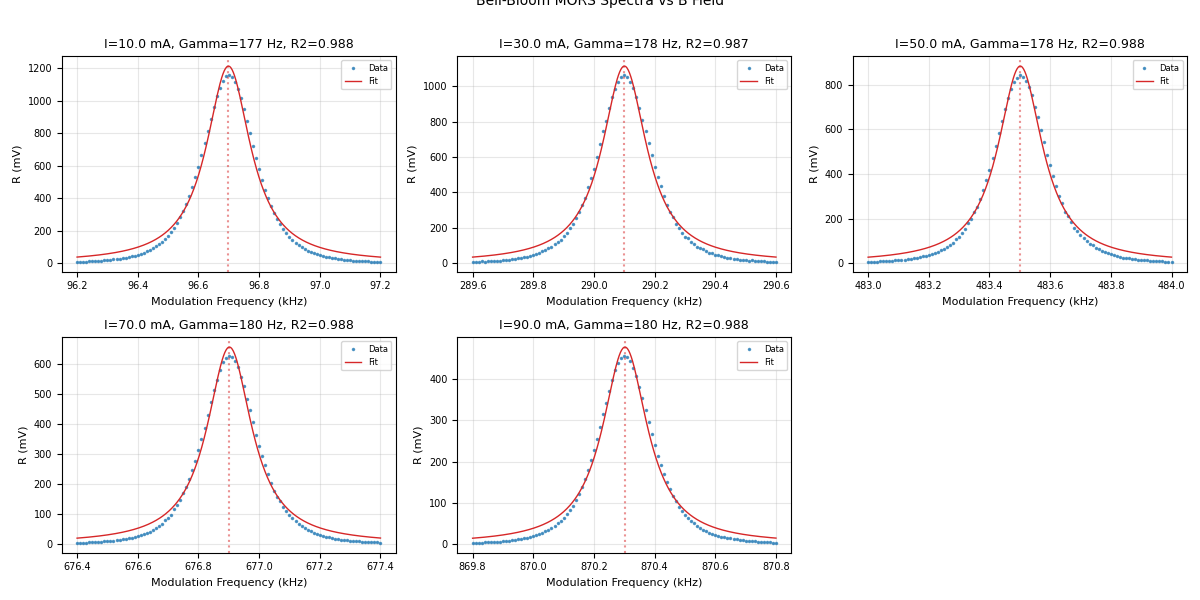

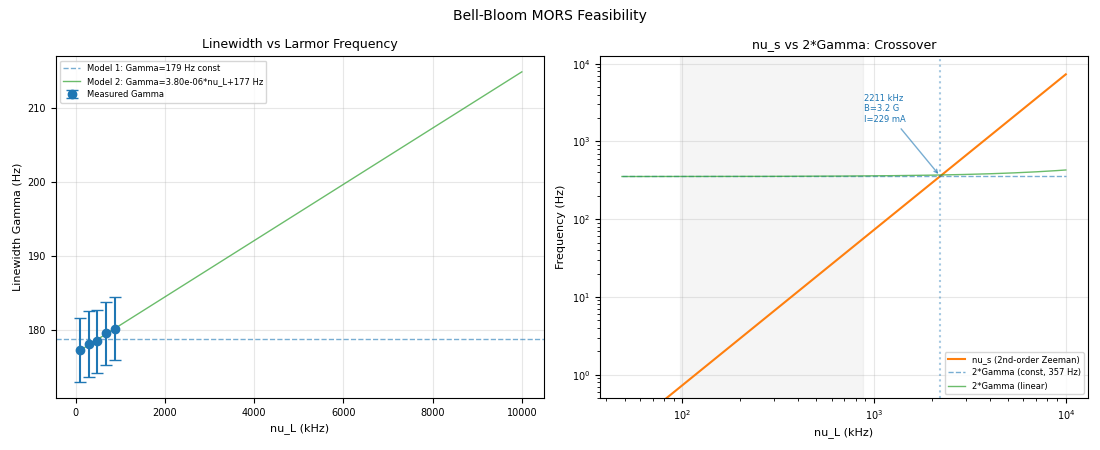


Feasibility
Model 1 (const Gamma): need I=229 mA, B=3.2 G
GS200 safety max: 101 mA
*** Exceeds safety range. Check coil rating, GS200 range, safety_limits.yaml ***


In [ ]:
# =====================================================================
# 可视化
# =====================================================================

plt.close('all')
_rc = {k: plt.rcParams[k] for k in ['font.size','axes.titlesize','axes.labelsize',
                                     'xtick.labelsize','ytick.labelsize','legend.fontsize']}
plt.rcParams.update({'font.size':8,'axes.titlesize':9,'axes.labelsize':8,
                     'xtick.labelsize':7,'ytick.labelsize':7,'legend.fontsize':7})

# Figure 1: 各 B 点 MORS 谱
n_plots = len(ok_results)
if n_plots > 0:
    n_cols = min(3, n_plots)
    n_rows = int(np.ceil(n_plots/n_cols))
    fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    if n_plots == 1:
        axes1 = np.array([axes1])
    axes1 = np.atleast_1d(axes1).flatten()
    for i, r in enumerate(ok_results):
        ax = axes1[i]
        ax.plot(r["freqs"]/1000, r["r_data"]*1e3, '.', color='C0', ms=3, alpha=0.7, label='Data')
        f_plot = np.linspace(r["freqs"][0], r["freqs"][-1], 500)
        r_plot = lorentzian(f_plot, r["A"], r["f0_Hz"], r["Gamma_Hz"], r["offset"])
        ax.plot(f_plot/1000, r_plot*1e3, 'C3-', lw=1.0, label='Fit')
        ax.axvline(r["f0_Hz"]/1000, color='C3', ls=':', alpha=0.5)
        ax.set_xlabel('Modulation Frequency (kHz)')
        ax.set_ylabel('R (mV)')
        ax.set_title(f"I={r['I_mA']:.1f} mA, Gamma={r['Gamma_Hz']:.0f} Hz, R2={r['r_squared']:.3f}")
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
    for j in range(n_plots, len(axes1)):
        axes1[j].set_visible(False)
    fig1.suptitle('Bell-Bloom MORS Spectra vs B Field', fontsize=10, y=1.01)
    fig1.tight_layout()
    fig1.savefig(results_dir/"mors_spectra_vs_B.png", dpi=150, bbox_inches="tight")
    plt.show()

# Figure 2: Gamma vs nu_L + 外推
if len(ok_results) >= 2:
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))
    ax_l = axes2[0]
    ax_l.errorbar(nu_L_arr/1000, Gamma_arr, yerr=Gamma_err_arr,
                  fmt='o', color='C0', capsize=4, ms=6, label='Measured Gamma')
    ax_l.axhline(Gamma_mean, color='C0', ls='--', lw=1.0, alpha=0.6,
                 label=f'Model 1: Gamma={Gamma_mean:.0f} Hz const')
    if not np.isnan(a_lin):
        ax_l.plot(nu_L_ext/1000, Gamma_ext_lin, 'C2-', lw=1.0, alpha=0.7,
                  label=f'Model 2: Gamma={a_lin:.2e}*nu_L+{b_lin:.0f} Hz')
    ax_l.set_xlabel('nu_L (kHz)'); ax_l.set_ylabel('Linewidth Gamma (Hz)')
    ax_l.set_title('Linewidth vs Larmor Frequency'); ax_l.legend(fontsize=6)
    ax_l.grid(True, alpha=0.3)

    ax_r = axes2[1]
    ax_r.loglog(nu_L_ext/1000, nu_s_ext, 'C1-', lw=1.5, label='nu_s (2nd-order Zeeman)')
    ax_r.loglog(nu_L_ext/1000, 2*Gamma_ext_const, 'C0--', lw=1.0, alpha=0.6,
                label=f'2*Gamma (const, {2*Gamma_mean:.0f} Hz)')
    if not np.isnan(a_lin):
        ax_r.loglog(nu_L_ext/1000, 2*Gamma_ext_lin, 'C2-', lw=1.0, alpha=0.7,
                    label='2*Gamma (linear)')
    ax_r.axvline(nu_L_needed_1/1000, color='C0', ls=':', alpha=0.4)
    ax_r.annotate(f'{nu_L_needed_1/1000:.0f} kHz\nB={B_needed_1:.1f} G\nI={I_needed_1:.0f} mA',
                  xy=(nu_L_needed_1/1000, 2*Gamma_mean),
                  xytext=(nu_L_needed_1/1000*0.4, 2*Gamma_mean*5),
                  arrowprops=dict(arrowstyle='->',color='C0',alpha=0.6), fontsize=6, color='C0')
    ax_r.axvspan(nu_L_arr[0]/1000, nu_L_arr[-1]/1000, color='gray', alpha=0.08)
    ax_r.set_xlabel('nu_L (kHz)'); ax_r.set_ylabel('Frequency (Hz)')
    ax_r.set_title('nu_s vs 2*Gamma: Crossover'); ax_r.legend(fontsize=6)
    ax_r.grid(True, alpha=0.3); ax_r.set_ylim(bottom=0.5)

    fig2.suptitle('Bell-Bloom MORS Feasibility', fontsize=10)
    fig2.tight_layout()
    fig2.savefig(results_dir/"feasibility_extrapolation.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n" + "="*60)
    print("Feasibility")
    print("="*60)
    print(f"Model 1 (const Gamma): need I={I_needed_1:.0f} mA, B={B_needed_1:.1f} G")
    print(f"GS200 safety max: {LIMITS['main_magnetic_field']['max']} mA")
    if I_needed_1 < LIMITS['main_magnetic_field']['max']:
        print(f"*** Within safety range! ***")
    else:
        print(f"*** Exceeds safety range. Check coil rating, GS200 range, safety_limits.yaml ***")

plt.rcParams.update(_rc)

In [ ]:
# ========== 安全断开 ==========

print("Disconnecting...")
try:
    gs.set_current(B_CURRENT_mA[0] / 1000.0)
    print(f"  B field restored: {B_CURRENT_mA[0]} mA")
except Exception as e:
    print(f"  B field restore failed: {e}")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} disconnected")
        except Exception as e:
            print(f"  {name} failed: {e}")

print("All done")

Disconnecting...
  B field restored: 10.0 mA
  gs200 disconnected
  dg_laser disconnected
  dg_mod disconnected
  dg_temp disconnected
  tec disconnected
  hf2 disconnected
All done
